In [71]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        os.path.join(dirname, filename)

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [72]:
!pip install transformers torchaudio librosa soundfile tqdm seaborn -q

In [73]:
import os
import pickle
import librosa
import numpy as np
import pandas as pd
import soundfile as sf

from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torchaudio

from transformers import (
    HubertModel,
    AutoFeatureExtractor
)

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    Bidirectional,
    LSTM,
    Reshape
)

In [74]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Using Device:", device)

Using Device: cuda


In [75]:
DATASET_PATH = "/kaggle/input/datasets/ejlok1/toronto-emotional-speech-set-tess/TESS Toronto emotional speech set data"

audio_files = []
labels = []

for folder in os.listdir(DATASET_PATH):

    folder_path = os.path.join(DATASET_PATH, folder)

    for file in os.listdir(folder_path):

        if file.endswith(".wav"):

            emotion = file.split("_")[-1].replace(".wav","")

            audio_files.append(
                os.path.join(folder_path, file)
            )

            labels.append(emotion)

print("Total Samples:", len(audio_files))

print(audio_files[0])
print(labels[0])

Total Samples: 2800
/kaggle/input/datasets/ejlok1/toronto-emotional-speech-set-tess/TESS Toronto emotional speech set data/YAF_fear/YAF_home_fear.wav
fear


In [76]:
le = LabelEncoder()

encoded_labels = le.fit_transform(labels)

print("Classes:")
print(le.classes_)

Classes:
['angry' 'disgust' 'fear' 'happy' 'neutral' 'ps' 'sad']


In [77]:
feature_extractor = AutoFeatureExtractor.from_pretrained(
    "facebook/hubert-base-ls960"
)

hubert = HubertModel.from_pretrained(
    "facebook/hubert-base-ls960"
).to(device)

hubert.eval()

print("HuBERT Loaded")

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

HuBERT Loaded


In [78]:
def extract_hubert_embedding(file_path):

    audio, sr = torchaudio.load(file_path)

    # stereo → mono
    if audio.shape[0] > 1:

        audio = torch.mean(
            audio,
            dim=0,
            keepdim=True
        )

    # resample
    if sr != 16000:

        resampler = torchaudio.transforms.Resample(
            sr,
            16000
        )

        audio = resampler(audio)

    audio = audio.squeeze()

    inputs = feature_extractor(
        audio,
        sampling_rate=16000,
        return_tensors="pt"
    )

    inputs = {
        k:v.to(device)
        for k,v in inputs.items()
    }

    with torch.no_grad():

        outputs = hubert(**inputs)

        hidden_states = outputs.last_hidden_state

    embedding = hidden_states.mean(
        dim=1
    ).cpu().numpy().squeeze()

    return embedding

In [79]:
FEATURE_CACHE = "/kaggle/input/models/akiraaravind/1/pytorch/default/1/hubert_features.npy"
LABEL_CACHE = "/kaggle/input/models/akiraaravind/1/pytorch/default/1/emotion_labels.npy"

if (
    os.path.exists(FEATURE_CACHE)
    and
    os.path.exists(LABEL_CACHE)
):

    print("Loading Cached Features...")

    X = np.load(FEATURE_CACHE)

    y = np.load(LABEL_CACHE)

else:

    print("Extracting HuBERT Features...")

    features = []

    for file in tqdm(audio_files):

        emb = extract_hubert_embedding(file)

        features.append(emb)

    X = np.array(features)

    y = np.array(encoded_labels)

    np.save(FEATURE_CACHE, X)

    np.save(LABEL_CACHE, y)

print("Feature Shape:", X.shape)
print("Labels Shape:", y.shape)

Loading Cached Features...
Feature Shape: (2800, 768)
Labels Shape: (2800,)


In [80]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (2240, 768)
Test Shape: (560, 768)


In [81]:
num_classes = len(le.classes_)

model = Sequential([

    Reshape(
        (1, 768),
        input_shape=(768,)
    ),

    Bidirectional(
        LSTM(
            128,
            return_sequences=False
        )
    ),

    Dropout(0.3),

    Dense(
        128,
        activation='relu'
    ),

    Dropout(0.3),

    Dense(
        num_classes,
        activation='softmax'
    )
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/reshape.py:38: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_4 (Reshape)             │ (None, 1, 768)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 256)            │       918,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 952,327 (3.63 MB)

 Trainable params: 952,327 (3.63 MB)

 Non-trainable params: 0 (0.00 B)

In [82]:
history = model.fit(

    X_train,
    y_train,

    validation_data=(
        X_test,
        y_test
    ),

    epochs=10,
    batch_size=32
)

Epoch 1/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.6768 - loss: 1.0721 - val_accuracy: 0.9804 - val_loss: 0.1685
Epoch 2/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9732 - loss: 0.1179 - val_accuracy: 0.9964 - val_loss: 0.0354
Epoch 3/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9906 - loss: 0.0418 - val_accuracy: 0.9911 - val_loss: 0.0220
Epoch 4/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9933 - loss: 0.0259 - val_accuracy: 0.9768 - val_loss: 0.0599
Epoch 5/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9955 - loss: 0.0216 - val_accuracy: 1.0000 - val_loss: 0.0070
Epoch 6/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9978 - loss: 0.0106 - val_accuracy: 0.9964 - val_loss: 0.0112
Epoch 7/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 1.0000 - loss: 0.0056 - val_accuracy: 1.0000 - val_loss: 0.0036
Epoch 8/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9991 - loss: 0.0056 - val_accuracy: 1.0000 - val_loss

In [83]:
y_pred_probs = model.predict(X_test)

y_pred = np.argmax(
    y_pred_probs,
    axis=1
)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=le.classes_,
        digits=6
    )
)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Accuracy: 0.9964285714285714

Classification Report:

              precision    recall  f1-score   support

       angry   1.000000  1.000000  1.000000        80
     disgust   0.987654  1.000000  0.993789        80
        fear   1.000000  1.000000  1.000000        80
       happy   0.987654  1.000000  0.993789        80
     neutral   1.000000  1.000000  1.000000        80
          ps   1.000000  0.975000  0.987342        80
         sad   1.000000  1.000000  1.000000        80

    accuracy                       0.996429       560
   macro avg   0.996473  0.996429  0.996417       560
weighted avg   0.996473  0.996429  0.996417       560



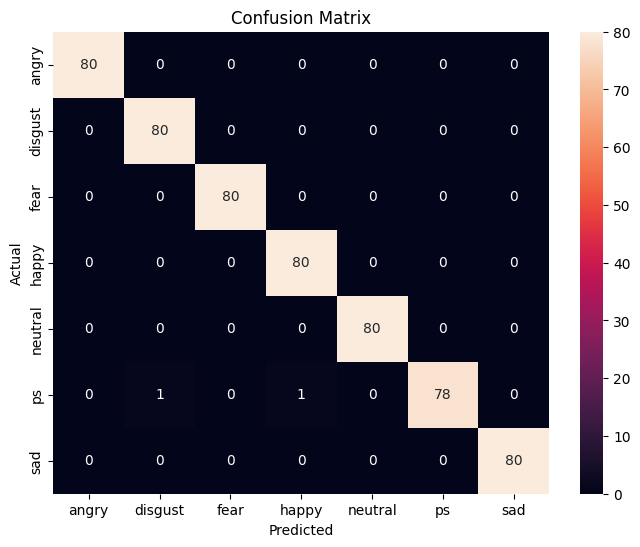

In [84]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

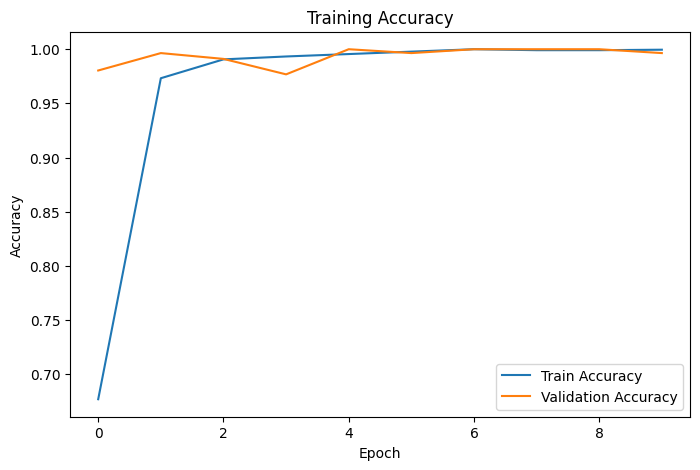

In [85]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Training Accuracy")

plt.legend()

plt.show()

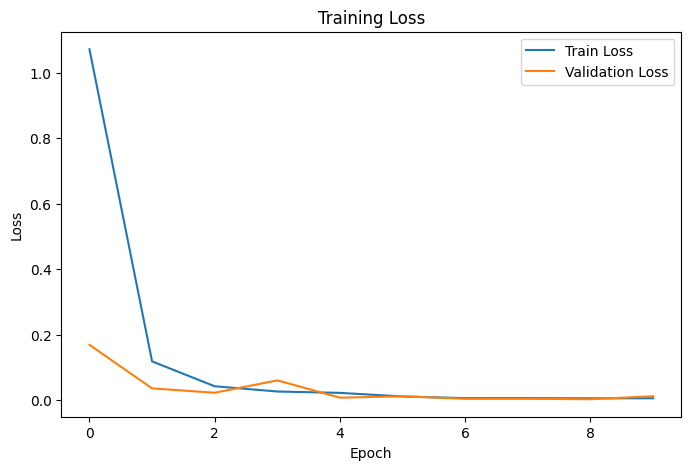

In [86]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label='Train Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training Loss")

plt.legend()

plt.show()

In [87]:
model.save(
    "speech_emotion_model.h5"
)

with open(
    "label_encoder.pkl",
    "wb"
) as f:

    pickle.dump(le, f)

print("Saved Successfully")

Saved Successfully
